Note: Use Python 3.9.18 or earlier version.

## Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.models import Model
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from imgaug import augmenters as iaa
import random

2025-01-09 22:50:19.440476: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load Dataset

Here, we are using numpy as Keras is used with numpy

In [2]:
## Load Dataset
def load_dataset():
    datasets = ['real', 'easy', 'medium', 'hard']
    data_dict = {}
    for dataset in datasets:
        x_data = np.load(f'dataset/x_{dataset}.npy')
        y_data = np.load(f'dataset/y_{dataset}.npy')
        data_dict[dataset] = (x_data, y_data)
        print(f"{dataset}: X shape {x_data.shape}, Y shape {y_data.shape}")

    return data_dict

data_dict = load_dataset()

real: X shape (6000, 90, 90), Y shape (6000, 4)
easy: X shape (17931, 90, 90), Y shape (17931, 4)
medium: X shape (17067, 90, 90), Y shape (17067, 4)
hard: X shape (14272, 90, 90), Y shape (14272, 4)


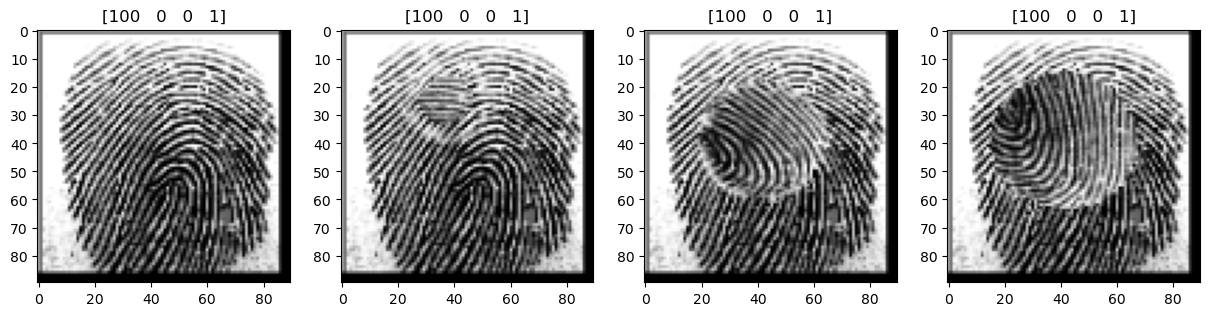

In [3]:
# Visualize a sample from each dataset
def visualize_samples(data_dict):
    plt.figure(figsize=(15, 10))
    for idx, (key, (x, y)) in enumerate(data_dict.items(), start=1):
        plt.subplot(1, 4, idx)
        plt.title(y[0])
        plt.imshow(x[0].squeeze(), cmap='gray')
    plt.show()

visualize_samples(data_dict)

# Train Test Split

In [4]:
x_data = np.concatenate([data_dict['easy'][0], data_dict['medium'][0], data_dict['hard'][0]], axis=0)
label_data = np.concatenate([data_dict['easy'][1], data_dict['medium'][1], data_dict['hard'][1]], axis=0)

# we use 90/10 split
x_train, x_val, label_train, label_val = train_test_split(x_data, label_data, test_size=0.1)
print(f"x_train: {x_train.shape}, label_train: {label_train.shape}")
print(f"x_val: {x_val.shape}, label_val: {label_val.shape}")

x_train: (44343, 90, 90), label_train: (44343, 4)
x_val: (4927, 90, 90), label_val: (4927, 4)


## Preview Augmentation

These are functions and transformations that will serve to transform and distort the original image that we will use for testing the trained model.


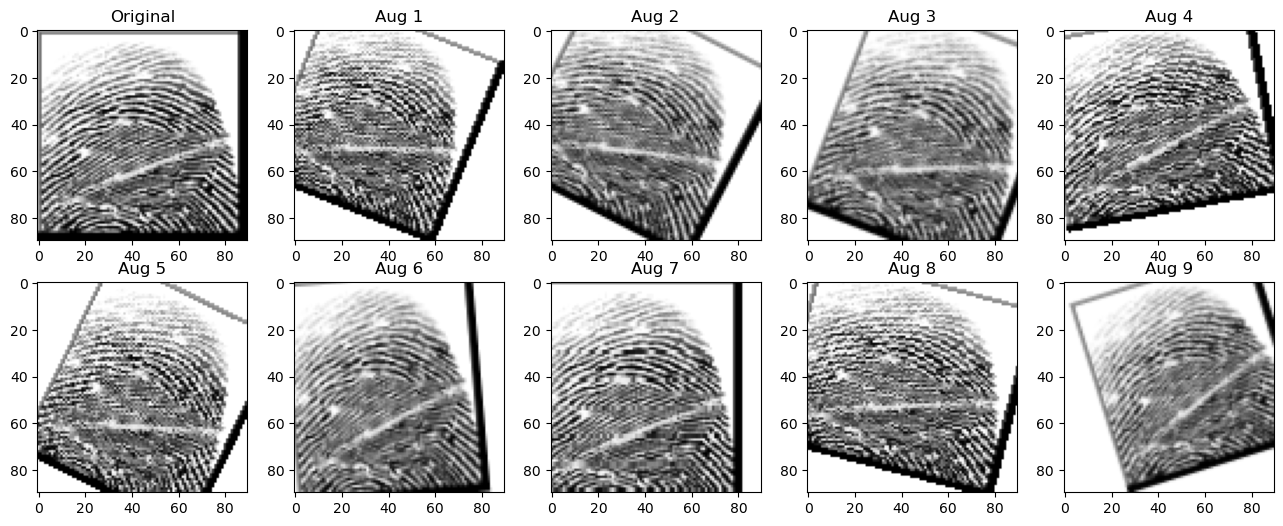

In [5]:
def preview_augmentation(images):
    seq = iaa.Sequential([
        iaa.GaussianBlur(sigma=(0, 0.5)),
        iaa.Affine(
            scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
            translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
            rotate=(-30, 30),
            order=[0, 1],
            cval=255
        )
    ], random_order=True)

    augmented_images = seq.augment_images(images)
    
    plt.figure(figsize=(16, 6))
    plt.subplot(2, 5, 1)
    plt.title('Original')
    plt.imshow(images[0].squeeze(), cmap='gray')
    for i, aug in enumerate(augmented_images):
        plt.subplot(2, 5, i + 2)
        plt.title(f'Aug {i + 1}')
        plt.imshow(aug.squeeze(), cmap='gray')
    plt.show()

preview_augmentation([x_data[40000]] * 9)

## Make Label Dictionary Lookup Table

This is used later on, to find the original index of a randomly picked sample from the validation set in order to compare the images for the testing.

In [6]:
label_real_dict = {''.join(y.astype(str)).zfill(6): i for i, y in enumerate(data_dict['real'][1])}

## Data Generator

This is necessary step in image processing using Keras, especially a big dataset that cannot fit into the memory during training. It is a class that produces batches of data that can feed into multiple cores right away.

In [7]:
class DataGenerator(keras.utils.Sequence):
    def __init__(self, x, label, x_real, label_real_dict, batch_size=32, shuffle=True):
        self.x = x
        self.label = label
        self.x_real = x_real
        self.label_real_dict = label_real_dict
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.x) // self.batch_size

    def __getitem__(self, index):
        x1_batch = self.x[index * self.batch_size:(index + 1) * self.batch_size]
        label_batch = self.label[index * self.batch_size:(index + 1) * self.batch_size]
        
        x2_batch = np.empty((self.batch_size, 90, 90, 1), dtype=np.float32)
        y_batch = np.zeros((self.batch_size, 1), dtype=np.float32)
        
        if self.shuffle:
            seq = iaa.Sequential([
                iaa.GaussianBlur(sigma=(0, 0.5)),
                iaa.Affine(scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
                           translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
                           rotate=(-30, 30),
                           order=[0, 1], cval=255)
            ], random_order=True)
            x1_batch = seq.augment_images(x1_batch)
        
        for i, l in enumerate(label_batch):
            match_key = ''.join(l.astype(str)).zfill(6)
            if random.random() > 0.5:
                x2_batch[i] = self.x_real[self.label_real_dict[match_key]]
                y_batch[i] = 1.
            else:
                while True:
                    unmatch_key, unmatch_idx = random.choice(list(self.label_real_dict.items()))
                    if unmatch_key != match_key:
                        x2_batch[i] = self.x_real[unmatch_idx]
                        break
                y_batch[i] = 0.
                
        return [x1_batch.astype(np.float32) / 255., x2_batch.astype(np.float32) / 255.], y_batch

    def on_epoch_end(self):
        if self.shuffle:
            self.x, self.label = shuffle(self.x, self.label)

In [8]:
# Here we create the DataGenerator class for train and validation set
train_gen = DataGenerator(x_train, label_train, data_dict['real'][0], label_real_dict)
val_gen = DataGenerator(x_val, label_val, data_dict['real'][0], label_real_dict, shuffle=False)

## Create Model

Here is the concept of the model:
- 2 models with 2x Convolutional and Pooling layers, sharing weights
- The outputs are subtracted, and the subtraction is fed to another Conv + Pooling layer
- Then that is fed to a sigmoid for final classification if the 2 images are same or not

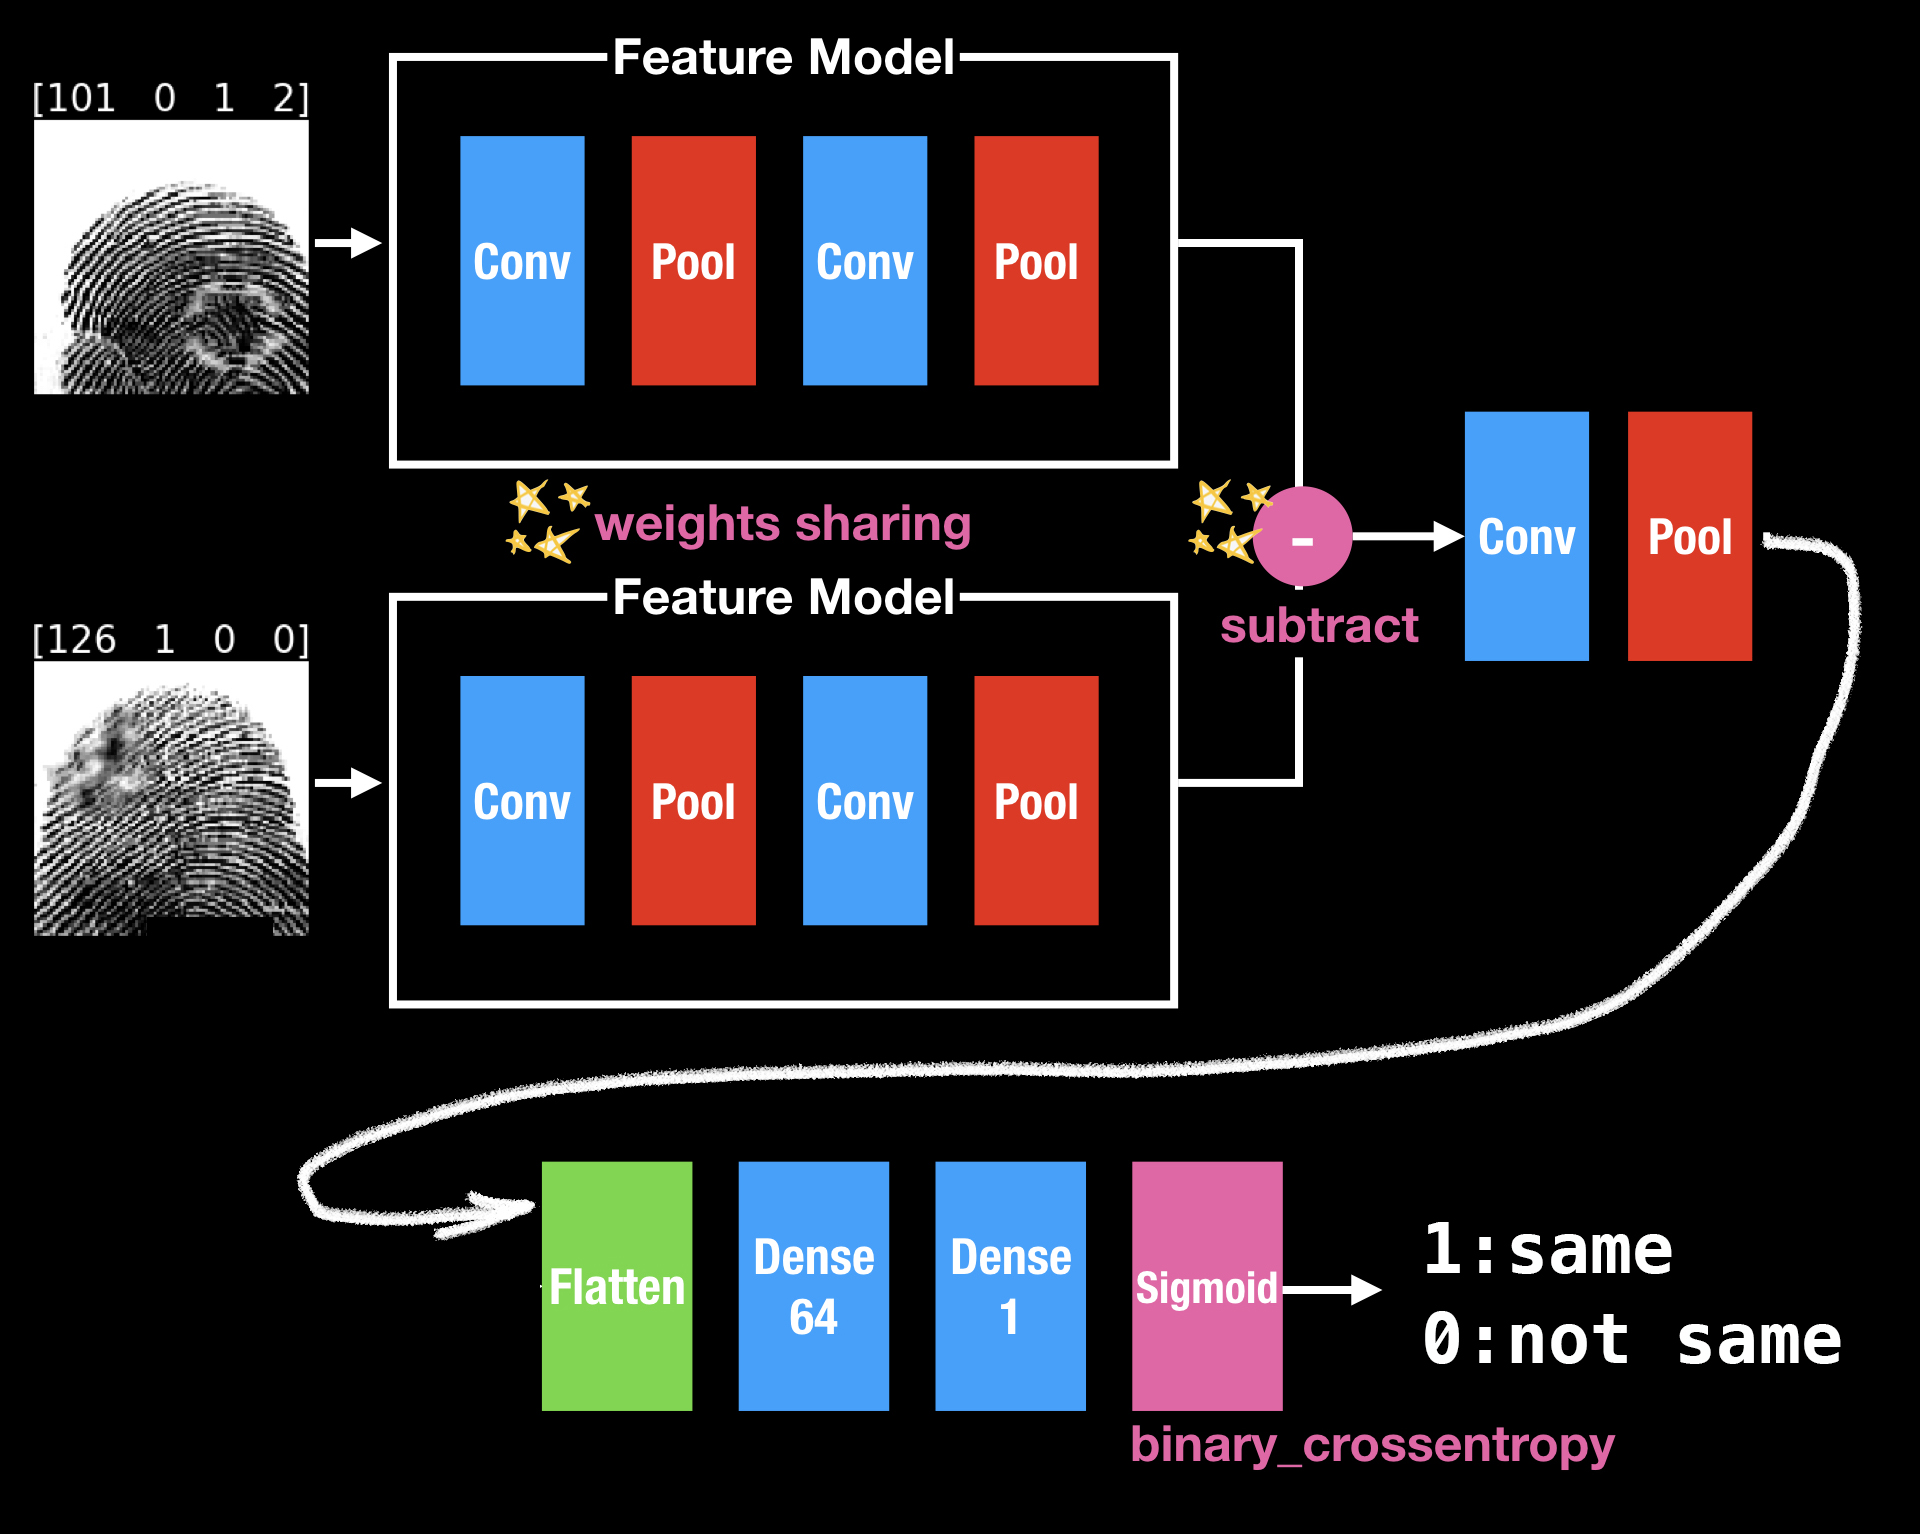

In [9]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Subtract
from tensorflow.keras.models import Model

def create_base_network(input_shape):
    """
    Function to create the base network (twin network) for the Siamese architecture.
    """
    input = Input(shape=input_shape)
    
    # First Convolutional Block
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    # Second Convolutional Block
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Flatten the feature map
    x = Flatten()(x)

    return Model(input, x)

# Define the input shape for the images
input_shape = (90, 90, 1)

# Create the twin networks (base networks with shared weights)
base_network = create_base_network(input_shape)

# Define two input tensors for the two images
input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

# Process each image through the shared twin network
processed_a = base_network(input_a)
processed_b = base_network(input_b)

# Compute the absolute difference between the feature vectors
subtracted = Subtract()([processed_a, processed_b])

# Further processing of the subtracted feature using another convolutional layer
x = Dense(128, activation='relu')(subtracted)
x = Dropout(0.5)(x)

# Output layer with sigmoid activation for binary classification
output = Dense(1, activation='sigmoid')(x)

# Create the full Siamese network model
model = Model(inputs=[input_a, input_b], outputs=output)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 90, 90, 1)]  0           []                               
                                                                                                  
 input_3 (InputLayer)           [(None, 90, 90, 1)]  0           []                               
                                                                                                  
 model (Functional)             (None, 30976)        18816       ['input_2[0][0]',                
                                                                  'input_3[0][0]']                
                                                                                                  
 subtract (Subtract)            (None, 30976)        0           ['model[0][0]',            

2025-01-09 22:50:31.043224: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Train

In other versons of the solutions, they used fit_generator method, which was commonly used in older versions of Keras to train models using data generators. However, since TensorFlow 2.1, fit can handle data generators directly. This unifies the API, making the code cleaner and more consistent. It also allows for better integration with TensorFlow’s functionalities such as distributed training and callbacks. Hence, using fit instead of fit_generator is the recommended approach now.

In [10]:
history = model.fit(train_gen, epochs=15, validation_data=val_gen)

ValueError: could not broadcast input array from shape (90,90) into shape (90,90,1)

## Evaluation

This is just a test using one random image and

1/1 [==============================] - 0s 18ms/step


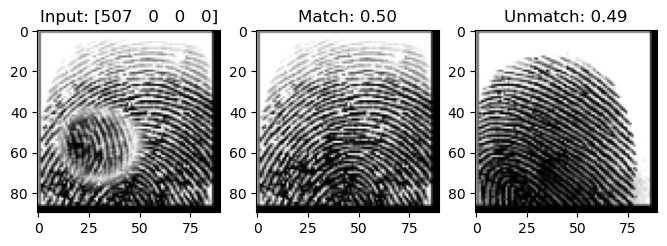

In [11]:
def evaluate_model(model, x_val, label_val):
    random_idx = random.randint(0, len(x_val))
    random_img = x_val[random_idx].reshape((1, 90, 90, 1)).astype(np.float32) / 255.
    match_key = ''.join(label_val[random_idx].astype(str)).zfill(6)
    
    matched_img = data_dict['real'][0][label_real_dict[match_key]].reshape((1, 90, 90, 1)).astype(np.float32) / 255.
    pred_matched = model.predict([random_img, matched_img])[0][0]
    
    unmatch_key, unmatch_idx = random.choice(list(label_real_dict.items()))
    unmatched_img = data_dict['real'][0][unmatch_idx].reshape((1, 90, 90, 1)).astype(np.float32) / 255.
    pred_unmatched = model.predict([random_img, unmatched_img])[0][0]

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 3, 1)
    plt.title(f'Input: {label_val[random_idx]}')
    plt.imshow(random_img.squeeze(), cmap='gray')
    plt.subplot(1, 3, 2)
    plt.title(f'Match: {pred_matched:.2f}')
    plt.imshow(matched_img.squeeze(), cmap='gray')
    plt.subplot(1, 3, 3)
    plt.title(f'Unmatch: {pred_unmatched:.2f}')
    plt.imshow(unmatched_img.squeeze(), cmap='gray')
    plt.show()

evaluate_model(model, x_val, label_val)

## Proper validation

The confusion matrix, Precision and AUC curve

@@ missing, add this

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assume y_true is your ground truth labels and y_pred are your model's predictions
# y_true = ...
# y_pred = ...

# First, you need to convert the predicted probabilities to class labels
# Let's assume that you have binary classification and you set a threshold of 0.5
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)

# Visualize confusion matrix using matplotlib
plt.figure(figsize=(10, 7))
plt.matshow(cm, cmap='viridis', fignum=1)
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Alternatively, you can use seaborn to create a more informative heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


NameError: name 'y_pred' is not defined

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions on the validation set
y_true = []
y_pred = []

# Collect true labels and predictions
for x_batch, y_batch in val_gen:
    predictions = model.predict(x_batch)
    y_true.extend(y_batch)
    y_pred.extend(predictions)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Convert predicted probabilities to class labels (assuming binary classification with a threshold of 0.5)
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)

# Visualize confusion matrix using matplotlib
plt.figure(figsize=(10, 7))
plt.matshow(cm, cmap='viridis', fignum=1)
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Alternatively, use seaborn to create a more informative heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print a classification report for more detailed metrics
print(classification_report(y_true, y_pred_labels))

ValueError: could not broadcast input array from shape (90,90) into shape (90,90,1)